# hw1 VSSD vs ResNet-18 на CIFAR-10

Для сравнения с VSSD я выбрала ResNet-18 — классическую сверточную сеть, baseline в задачах классификации изображений.
Это позволит оценить - дает ли новая архитектура с глобальным контекстом реальный выигрыш над проверенным локальным CNN-подходом.


In [3]:
!pip uninstall torch torchvision torchaudio -y
!pip install torch==2.5.1 torchvision==0.20.1 torchaudio==2.5.1 --index-url https://download.pytorch.org/whl/cu124

!pip install https://github.com/Dao-AILab/causal-conv1d/releases/download/v1.5.0.post8/causal_conv1d-1.5.0.post8+cu12torch2.5cxx11abiFALSE-cp312-cp312-linux_x86_64.whl

!pip install https://github.com/state-spaces/mamba/releases/download/v2.2.4/mamba_ssm-2.2.4+cu12torch2.5cxx11abiFALSE-cp312-cp312-linux_x86_64.whl

!git clone https://github.com/YuHengsss/VSSD.git
!pip install packaging triton timm==0.4.12 pytest chardet yacs termcolor submitit tensorboardX fvcore seaborn opencv-python tensorboard

!pip install transformers==4.40.0

Looking in indexes: https://download.pytorch.org/whl/cu124
  Using cached https://download-r2.pytorch.org/whl/cu124/torch-2.5.1%2Bcu124-cp312-cp312-linux_x86_64.whl (908.2 MB)
  Using cached https://download-r2.pytorch.org/whl/cu124/torchvision-0.20.1%2Bcu124-cp312-cp312-linux_x86_64.whl (7.3 MB)
  Using cached https://download-r2.pytorch.org/whl/cu124/torchaudio-2.5.1%2Bcu124-cp312-cp312-linux_x86_64.whl (3.4 MB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 79.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 57.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 98.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.7 MB/s eta 0:00:00
     ━━━━━━━━━━

### Конфигурация эксперимента

- **Dataset:** CIFAR-10 (50 000 train / 10 000 test, 10 классов, 32×32 px)
- **VSSD:** VSSD-Micro, patch_size=4, d_state=16, Non-Causal SSM, Multi-Scan (4 направления), 14M параметров
- **Baseline:** ResNet-18, адаптированный под 32×32 (conv1: 7×7->3×3, без maxpool), 11M параметров
- **Epochs:** 35, batch_size: 128
- **Optimizer:** AdamW, lr=3e-4, weight_decay=0.05
- **Scheduler:** CosineAnnealingLR
- **Device:** NVIDIA T4

In [4]:
import os
import sys
import time
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import models
from torch.utils.data import DataLoader

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Устройство: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Устройство: cuda
GPU: Tesla T4


In [7]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
NUM_CLASSES  = 10
BATCH_SIZE   = 128
EPOCHS       = 35
LR           = 3e-4
WEIGHT_DECAY = 0.05
IMG_SIZE     = 32

In [8]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2023, 0.1994, 0.2010)
    )
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2023, 0.1994, 0.2010)
    )
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
testset  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
testloader  = DataLoader(testset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

classes = trainset.classes
print(f"Классы: {classes}")
print(f"Train: {len(trainset)} | Test: {len(testset)}")


100%|██████████| 170M/170M [00:06<00:00, 28.1MB/s]


Extracting ./data/cifar-10-python.tar.gz to ./data
Files already downloaded and verified
Классы: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Train: 50000 | Test: 10000


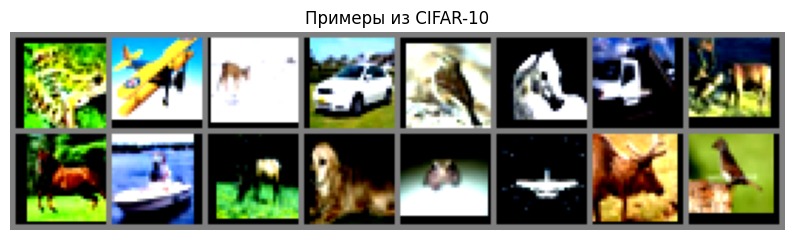

['frog', 'airplane', 'deer', 'automobile', 'bird', 'horse', 'truck', 'deer', 'horse', 'ship', 'deer', 'dog', 'frog', 'airplane', 'deer', 'bird']


In [9]:
def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.figure(figsize=(10, 4))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.title('Примеры из CIFAR-10')
    plt.show()

dataiter = iter(trainloader)
images, labels = next(dataiter)
imshow(torchvision.utils.make_grid(images[:16]))
print([classes[x] for x in labels[:16]])


In [12]:
criterion = nn.CrossEntropyLoss()

def train_model(model, epochs=35):
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    train_losses = []
    train_accs   = []
    best_model   = copy.deepcopy(model.state_dict())
    best_acc     = 0

    for epoch in range(epochs):
        model.train()
        running_loss = 0
        correct = 0
        total   = 0

        loop = tqdm(trainloader, desc=f"Epoch [{epoch+1}/{epochs}]")

        for images, labels in loop:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted  = outputs.max(1)
            total        += labels.size(0)
            correct      += predicted.eq(labels).sum().item()

        scheduler.step()

        epoch_loss = running_loss / len(trainloader)
        epoch_acc  = 100. * correct / total
        train_losses.append(epoch_loss)
        train_accs.append(epoch_acc)

        print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.2f}%")

        if epoch_acc > best_acc:
            best_acc   = epoch_acc
            best_model = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_model)
    return model, train_losses, train_accs


def evaluate(model):
    model.eval()
    correct = 0
    total   = 0
    with torch.no_grad():
        for images, labels in testloader:
            images  = images.to(device)
            labels  = labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total   += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return 100. * correct / total


In [13]:
resnet18 = models.resnet18(weights=None, num_classes=10)
resnet18.conv1   = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
resnet18.maxpool = nn.Identity()
resnet18 = resnet18.to(device)

params = sum(p.numel() for p in resnet18.parameters() if p.requires_grad)
print(f"ResNet-18 параметры: {params/1e6:.2f}M")


ResNet-18 параметры: 11.17M


In [17]:
start = time.time()
resnet18, resnet_losses, resnet_accs = train_model(resnet18, epochs=EPOCHS)
resnet_time = time.time() - start

resnet_test_acc = evaluate(resnet18)
print(f"ResNet-18 Test Accuracy: {resnet_test_acc:.2f}%")
print(f"Время обучения: {resnet_time/60:.1f} мин")


Epoch [1/35]: 100%|██████████| 391/391 [00:43<00:00,  8.97it/s]


Epoch 1, Loss: 1.1417, Acc: 59.22%


Epoch [2/35]: 100%|██████████| 391/391 [00:43<00:00,  9.05it/s]


Epoch 2, Loss: 0.8193, Acc: 71.10%


Epoch [3/35]: 100%|██████████| 391/391 [00:43<00:00,  8.98it/s]


...

Epoch [34/35]: 100%|██████████| 391/391 [00:43<00:00,  9.02it/s]


Epoch 34, Loss: 0.0222, Acc: 99.41%


Epoch [35/35]: 100%|██████████| 391/391 [00:43<00:00,  8.97it/s]

Epoch 35, Loss: 0.0210, Acc: 99.39%


ResNet-18 Test Accuracy: 91.58%
Время обучения: 25.3 мин


In [28]:
import sys
sys.path.insert(0, '/content/VSSD/classification')

import argparse
from models import build_model
from config import get_config

args = argparse.Namespace(
    cfg   = "/content/VSSD/classification/configs/vssd/vssd_micro_e300.yaml",
    opts  = None,
    batch_size = BATCH_SIZE,
    data_path  = None,
    resume     = None,
    pretrained = None,
    output     = None,
    eval       = False,
    amp_opt_level = "",
    tag        = None,
    throughput = False,
    local_rank = 0,
)

config = get_config(args)


config.defrost()
config.MODEL.NUM_CLASSES = 10
config.DATA.IMG_SIZE     = 32
config.freeze()

vssd_model = build_model(config)
vssd_model = vssd_model.to(device)

params = sum(p.numel() for p in vssd_model.parameters() if p.requires_grad)
print(f"VSSD-Micro параметры: {params/1e6:.2f}M")
print(f"Тип модели: {type(vssd_model).__name__}")

x_test = torch.randn(2, 3, 32, 32).to(device)
with torch.no_grad():
    out = vssd_model(x_test)


=> merge config from /content/VSSD/classification/configs/vssd/vssd_micro_e300.yaml
VSSD-Micro параметры: 13.51M
Тип модели: VMAMBA2


In [16]:
start = time.time()
vssd_model, vssd_losses, vssd_accs = train_model(vssd_model, epochs=EPOCHS)
vssd_time = time.time() - start

vssd_test_acc = evaluate(vssd_model)
print(f"VSSD Test Accuracy: {vssd_test_acc:.2f}%")
print(f"Время обучения: {vssd_time/60:.1f} мин")


Epoch [1/35]: 100%|██████████| 391/391 [01:02<00:00,  6.28it/s]


Epoch 1, Loss: 1.7796, Acc: 38.25%


Epoch [2/35]: 100%|██████████| 391/391 [01:00<00:00,  6.45it/s]


Epoch 2, Loss: 1.3559, Acc: 50.87%


Epoch [3/35]: 100%|██████████| 391/391 [01:00<00:00,  6.43it/s]


...

Epoch 33, Loss: 0.2365, Acc: 91.63%


Epoch [34/35]: 100%|██████████| 391/391 [01:00<00:00,  6.44it/s]


Epoch 34, Loss: 0.2308, Acc: 91.92%


Epoch [35/35]: 100%|██████████| 391/391 [00:59<00:00,  6.53it/s]


Epoch 35, Loss: 0.2289, Acc: 91.96%
VSSD Test Accuracy: 83.16%
Время обучения: 35.1 мин


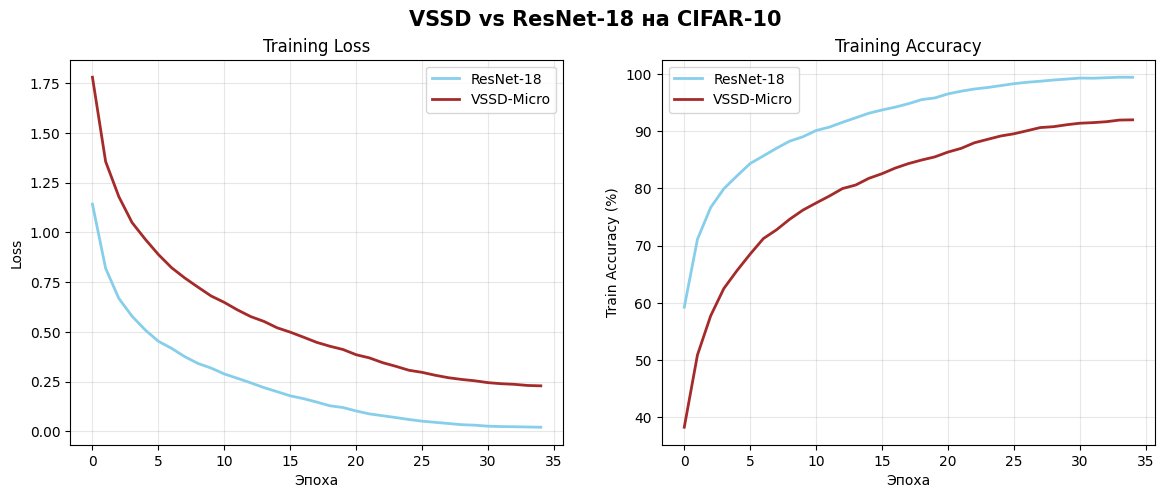

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("VSSD vs ResNet-18 на CIFAR-10", fontsize=15, fontweight="bold")

# Loss
axes[0].plot(resnet_losses, label="ResNet-18", color="skyblue", linewidth=2)
axes[0].plot(vssd_losses,   label="VSSD-Micro", color="brown", linewidth=2)
axes[0].set_xlabel("Эпоха")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(resnet_accs, label="ResNet-18", color="skyblue", linewidth=2)
axes[1].plot(vssd_accs,   label="VSSD-Micro", color="brown", linewidth=2)
axes[1].set_xlabel("Эпоха")
axes[1].set_ylabel("Train Accuracy (%)")
axes[1].set_title("Training Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.show()


In [20]:
resnet_params = sum(p.numel() for p in resnet18.parameters()   if p.requires_grad)
vssd_params   = sum(p.numel() for p in vssd_model.parameters() if p.requires_grad)

results = pd.DataFrame({
    "Модель"            : ["ResNet-18", "VSSD-Micro"],
    "Test Accuracy (%)" : [round(resnet_test_acc, 2), round(vssd_test_acc, 2)],
    "Параметры (M)"     : [round(resnet_params/1e6, 1), round(vssd_params/1e6, 1)],
    "Время обучения (мин)": [round(resnet_time/60, 1), round(vssd_time/60, 1)],
    "Механизм"          : ["Local Conv (3x3)", "Non-Causal SSM + Multi-Scan"],
})
print(results.to_string(index=False))

delta = vssd_test_acc - resnet_test_acc
print(f"delta VSSD vs ResNet-18: {delta:+.2f}%")

    Модель  Test Accuracy (%)  Параметры (M)  Время обучения (мин)                    Механизм
 ResNet-18              91.58           11.2                  25.3            Local Conv (3x3)
VSSD-Micro              83.16           13.5                  35.1 Non-Causal SSM + Multi-Scan
delta VSSD vs ResNet-18: -8.42%


В эксперименте на CIFAR-10 ResNet-18 показал точность **91.58%**, VSSD-Micro — **83.16%**.
ResNet-18 оказался точнее на 8.42%, при этом обучался быстрее (25 и 35 минут) и имеет меньше параметров (11.2M и 13.5M).

Такой результат предсказуем. Я брала - CIFAR-10, а это маленькие изображения 32×32,где локальные свертки ResNet работают хорошо. Глобальный контекст, который дает VSSD через Non-Causal SSM, на таком маленьком разрешении не дает преимущества — просто нечего "видеть издалека" в маленькой картинке :c

VSSD раскрывает свой потенциал на высоком разрешении (224×224 и выше), где
квадратичная сложность Transformer становится проблемой, а линейный SSM выигрывает(как обсуждалось)
поэтому в оригинальной статье все эксперименты проводились на ImageNet 224×224,а не на CIFAR-10.

In [26]:
import torch

torch.save(resnet18.state_dict(),   "resnet18_cifar10.pth")
torch.save(vssd_model.state_dict(), "vssd_cifar10.pth")